# Figure 3

![Full Figure](../figures/fig03_FULL.png)

## Code For Figure 3A–C: Probe Violation Rates vs Training Time

**Goal:** Show that FixGrower-trained animals maintain low violation rates in probe stages predicted by training time.

| Panel | Description | Data source |
|-------|-------------|-------------|
| A | Violation rate: stable (stage 9), random (stage 10), combined probe sessions | `trials_df` (session-level) |
| B | Violation rate over probe days (day 0 = first random-probe day) | `trials_df` |
| C | Days to 2 s target vs combined probe violation rate (R047 excluded from model) | `trials_df` |

**Outputs:** `figures/fig03a_probe_violation_rates.png`, `fig03b_probe_violation_over_days.png`, `fig03c_probe_violation_vs_days_to_target.png`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from fixation_grower import config
from fixation_grower.io import load_poke_df, load_trials_df
from fixation_grower.plotting import box_strip_legacy_vs_fixgrower, save_figure
from fixation_grower.stats import (
    compare_fig03_panel_a_stats_holm,
    compare_legacy_fixgrower_mixedlm,
    compare_probe_violation_interaction_mixedlm,
)
from fixation_grower.transforms import (
    compute_days_relative_to_stage,
    make_days_to_target_df,
    make_probe_violation_session_df,
)

sns.set_context(
    "notebook",
    rc={
        "font.size": 18,
        "axes.titlesize": 18,
        "axes.labelsize": 18,
        "axes.titleweight": "bold",
        "xtick.labelsize": 15,
        "ytick.labelsize": 15,
        "lines.linewidth": 2,
        "lines.markersize": 7,
    },
)

In [2]:
REL_STAGE_TARGET = 5
REL_STAGE_PROBE_ALIGN = 10
PROBE_CATEGORY_ORDER = ["Stable", "Random", "Combined"]

tdf = load_trials_df()
tdf = compute_days_relative_to_stage(tdf, stage=REL_STAGE_TARGET)
tdf = compute_days_relative_to_stage(tdf, stage=REL_STAGE_PROBE_ALIGN)

probe_violation_df = make_probe_violation_session_df(tdf)
days_to_target = make_days_to_target_df(tdf)

probe_time_and_viol_df = probe_violation_df.merge(
    days_to_target, on=["animal_id", "fix_experiment"], how="left"
)
probe_time_and_viol_df["outlier"] = (
    probe_time_and_viol_df["animal_id"] == config.PROBE_OUTLIER
)

## Panel A — Probe stage violation rates

Session-level mean violation rate (%) per animal and date. Dots are individual sessions; boxes span the interquartile range with a line at the median.

/var/folders/3k/r4ptbl4s1_lcy5t6h9k08ptw0000gt/T/ipykernel_26987/3597269474.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


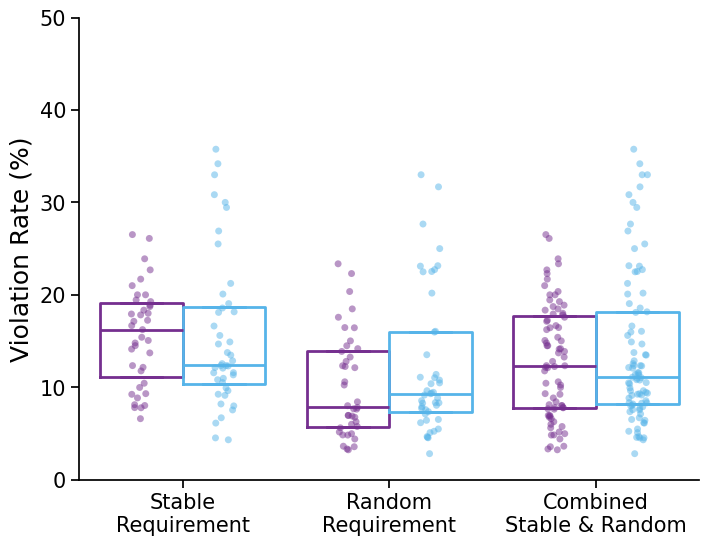

In [3]:
stable_random = probe_violation_df.assign(
    probe_category=probe_violation_df["stage"].map({9: "Stable", 10: "Random"})
)
combined = probe_violation_df.assign(probe_category="Combined")
panel_a_df = pd.concat([stable_random, combined], ignore_index=True)

fig, ax = plt.subplots(figsize=(8, 6))
box_strip_legacy_vs_fixgrower(
    panel_a_df,
    x="probe_category",
    order=PROBE_CATEGORY_ORDER,
    y="violation_rate",
    ax=ax,
    xlabel="",
    ylabel="Violation Rate (%)",
    dodge=True,
    alpha=0.5,
    width=0.8,
)
ax.set_ylim(0, 50)
ax.set_xticklabels([
    "Stable\nRequirement",
    "Random\nRequirement",
    "Combined\nStable & Random",
])
ax.legend().remove()
sns.despine(ax=ax)
save_figure(fig, "fig03a_probe_violation_rates")

### Panel A statistics

Across-cohort comparisons use Mann–Whitney U (or Welch's t when both groups pass Shapiro–Wilk). Within-cohort stable-vs-random comparisons use Wilcoxon signed-rank tests on animal-level means. All four raw p-values are Holm-corrected together (legacy notebook pooling).

In [4]:
stats_a = compare_fig03_panel_a_stats_holm(probe_violation_df)
display(stats_a)

print("\nSupplementary mixed LM on combined probe sessions (session-level):")
display(compare_legacy_fixgrower_mixedlm(probe_violation_df, "violation_rate"))

,comparison,test_type,test_statistic,p_val_raw,n_Legacy,n_FixGrower,n_pairs,p_val_holm,reject_h0_holm
0,across_stable_stage9,mannwhitney,947.5,0.416759,39.0,44.0,NaN,0.465730,0.0
1,across_random_stage10,mannwhitney,764.0,0.232865,40.0,45.0,NaN,0.465730,0.0
2,within_Legacy_stable_vs_random,wilcoxon_signed_rank,1.0,0.015625,NaN,NaN,8.0,0.046875,1.0
3,within_FixGrower_stable_vs_random,wilcoxon_signed_rank,2.0,0.011719,NaN,NaN,9.0,0.046875,1.0



Supplementary mixed LM on combined probe sessions (session-level):


,test_type,test_statistic,p_val_raw,residuals_normal
0,mixedlm_random_intercept,0.37315,0.709037,False


## Panel B — Violation rates over probe days

Day 0 is the first day of the random probe stage (`days_relative_to_stage_10`). Shading is standard error of the mean across sessions.

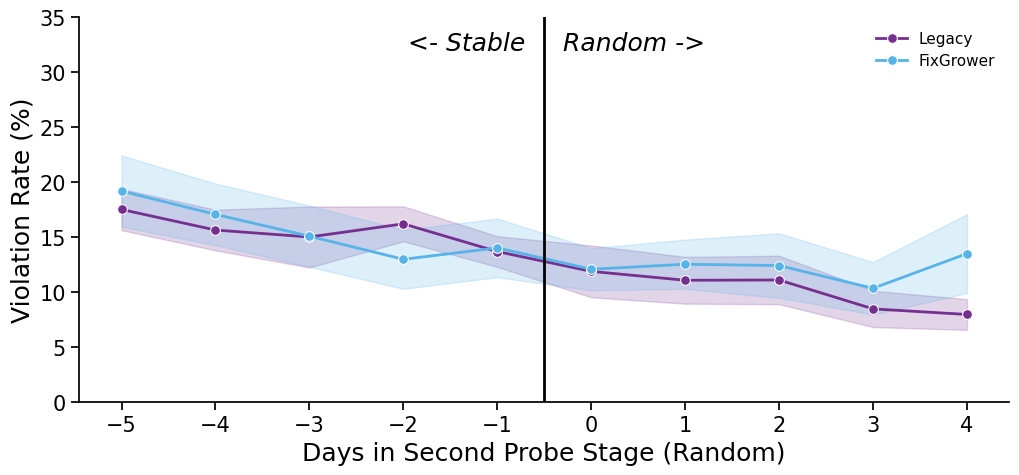

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.despine()
sns.lineplot(
    data=probe_violation_df,
    x="days_relative_to_stage_10",
    y="violation_rate",
    hue="fix_experiment",
    hue_order=config.HUE_ORDER_EXP,
    palette=config.EXP_PALETTE,
    marker="o",
    errorbar="se",
    ax=ax,
)
ax.set_ylim(0, 35)
ax.set_xticks(range(-5, 5))
ax.axvline(-0.5, color="black")
ax.text(-0.3, 32, "Random ->", ha="left", fontstyle="italic")
ax.text(-0.7, 32, "<- Stable", ha="right", fontstyle="italic")
ax.set(
    xlabel="Days in Second Probe Stage (Random)",
    ylabel="Violation Rate (%)",
)
ax.legend(title="", frameon=False)
save_figure(fig, "fig03b_probe_violation_over_days")

## Panel C — Probe performance by training time

Each point is one animal (mean violation rate across probe sessions with SEM). The FixGrower outlier `R047` is marked with an X and excluded from the mixed-effects model below.

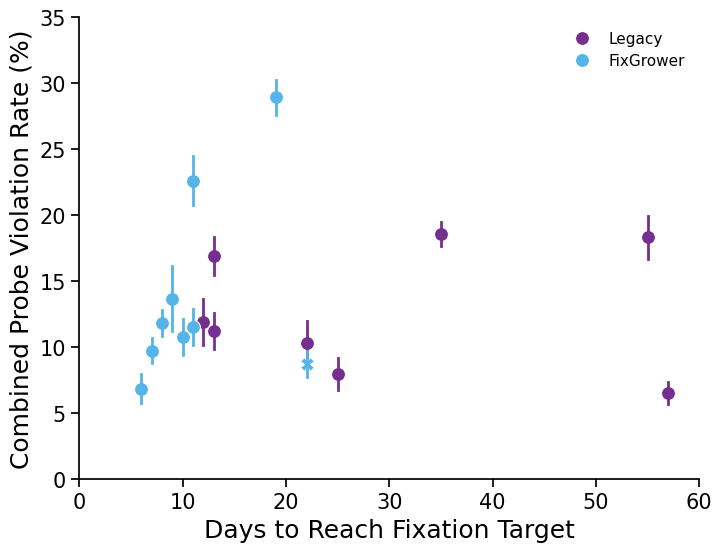

In [21]:
import warnings
warnings.filterwarnings(
    "ignore",
    message="Calling float on a single element Series is deprecated",
    category=FutureWarning,
)

fig, ax = plt.subplots(figsize=(8, 6))
sns.lineplot(
    data=probe_time_and_viol_df.query("animal_id != @config.PROBE_OUTLIER"),
    x="days_to_target",
    y="violation_rate",
    hue="fix_experiment",
    palette=config.EXP_PALETTE,
    hue_order=config.HUE_ORDER_EXP,
    style="animal_id",
    marker="o",
    markersize=10,
    linestyle="",
    err_style="bars",
    errorbar="se",
    ax=ax,
)
sns.lineplot(
    data=probe_time_and_viol_df.query("animal_id == @config.PROBE_OUTLIER"),
    x="days_to_target",
    y="violation_rate",
    hue="fix_experiment",
    palette=config.EXP_PALETTE,
    hue_order=config.HUE_ORDER_EXP,
    style="animal_id",
    marker="X",
    markersize=10,
    linestyle="",
    err_style="bars",
    errorbar="se",
    ax=ax,
)
ax.set(xlim=(0, 60), ylim=(0, 35))
ax.set_xlabel("Days to Reach Fixation Target")
ax.set_ylabel("Combined Probe Violation Rate (%)")
sns.despine(ax=ax)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles[1:3], labels=labels[1:3], frameon=False)
save_figure(fig, "fig03c_probe_violation_vs_days_to_target")

### Panel C statistics

Mixed-effects model: `violation_rate ~ days_to_target * fix_experiment` with random intercept for `animal_id`, excluding `config.PROBE_OUTLIER`.

In [7]:
stats_c_excluded = compare_probe_violation_interaction_mixedlm(
    probe_time_and_viol_df,
    exclude_animals=(config.PROBE_OUTLIER,),
)
print(f"Mixed LM excluding {config.PROBE_OUTLIER}:")
display(stats_c_excluded)

Mixed LM excluding R047:


/opt/miniconda3/envs/fixation-grower/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


,term,test_type,excluded_animals,test_statistic,p_val_raw,coef,residuals_normal
0,Intercept,mixedlm_random_intercept,"(R047,)",4.122991,0.000037,12.549574,False
1,"C(fix_experiment, Treatment(reference=""Legacy""...",mixedlm_random_intercept,"(R047,)",-2.728212,0.006368,-14.733073,False
2,days_to_target,mixedlm_random_intercept,"(R047,)",0.073383,0.941501,0.006636,False
3,"days_to_target:C(fix_experiment, Treatment(ref...",mixedlm_random_intercept,"(R047,)",3.881111,0.000104,1.640558,False
4,Group Var,mixedlm_random_intercept,"(R047,)",2.090891,0.036538,0.816430,False


In [23]:
stats_c_included = compare_probe_violation_interaction_mixedlm(
    probe_time_and_viol_df,
    exclude_animals=(),
)
print(f"Mixed LM including all animals:")
display(stats_c_included)

Mixed LM including all animals:


,term,test_type,excluded_animals,test_statistic,p_val_raw,coef,residuals_normal
0,Intercept,mixedlm_random_intercept,(),2.912525,0.003585,12.558198,False
1,"C(fix_experiment, Treatment(reference=""Legacy""...",mixedlm_random_intercept,(),-0.707090,0.479511,-4.697578,False
2,days_to_target,mixedlm_random_intercept,(),0.048190,0.961565,0.006168,False
3,"days_to_target:C(fix_experiment, Treatment(ref...",mixedlm_random_intercept,(),1.224187,0.220882,0.517312,False
4,Group Var,mixedlm_random_intercept,(),2.316587,0.020526,1.800818,False
